## Importance Estimation Strategies

This notebook explores the different block/mlp importance estimation strategies for effective operator construction/compression strategy selection.

This notebook asks whether Block Influence is
associated with how accurately each MLP can be approximated by a bias-free
dense linear map.

### Screening Pipeline ideas

#### 1. BI-score vs. Dense Linear Replacement Loss

BI-score is the most common used heuristic for estimating block importance, the idea is to fit a dense linear layer (all blocks) and analyze their respective losses. Linear layers might tell us more regarding the non-linearity of blocks, which might be hard to estimate using purely BI-score.

idea: fit $Wx$ and compare its loss (e.g. norm MSE) against $BI$ (correlation). High loss blocks signal non-linearity.
- Additionaly comparing different compute budgets could be maybe useful (calibration split >>>)

- alternative: use BI-score, MLP-score, Dense-Linear Loss

Pros:
- fast: forward-pass only

Cons:

### Budget Allocation ideas

#### 2. Operator Sparsity %

After computing operator importance we calculate the targeted sparsity per block, we could derive this from model level sparsity and then optimize through linear programming with constraints being
individual block importances.

- skip mask: could be useful maybe to letft the most important blocks alone and keep original operator
- alternative: create smaller operator with enough expressive power

#### 3. Model Sparsity %

Instead of the $k$-block replacement approach maybe we could define a target model level sparsity (per axes, e.g. prunning/replacement/architectural redundancy) and distribute the sparsity % downstream based on importance scores.

setup

In [1]:
from dataclasses import asdict
from pathlib import Path
import json
import sys

def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "mlp_replacement").is_dir():
            return candidate
    raise RuntimeError("Could not locate the repository root")

PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
import pprint

from mlp_replacement.capture import collect_modules_io
from mlp_replacement.config import DataConfig, ModelConfig
from mlp_replacement.data import build_data_loaders
from mlp_replacement.evaluation.operator import evaluate_operator
from mlp_replacement.model import discover_mlp_blocks, load_model_and_tokenizer
from mlp_replacement.operators import fit_ridge_linear
from mlp_replacement.runlog import environment_record, json_value
from mlp_replacement.screening import compute_bi_scores, compute_mlp_bi_scores, compute_raw_mlp_input_output_scores

sns.set_theme(style="whitegrid", context="notebook")

config

In [2]:
SEED = 21
DEVICE = 'cuda'

torch.manual_seed(SEED)

In [3]:
RIDGE = 1e-4
EVALUATION_BATCH_SIZE = 2048

EXCLUDED_LAYERS = {0, 23}

OUTPUT_PATH = (
    PROJECT_ROOT
    / "data"
    / "results"
    / "notebook-analyses"
    / "importance-bi-vs-dense-linear.json"
)

data/model

In [4]:
model_config = ModelConfig(
    model_id="HuggingFaceTB/SmolLM2-1.7B",
    device=DEVICE,
    dtype="auto",
)

data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=0,
    num_recovery_validation_batches=0,
    num_model_validation_batches=1,
    num_test_batches=0,
    seed=SEED,
)

model, tokenizer = load_model_and_tokenizer(model_config)
device = next(model.parameters()).device
loaders = build_data_loaders(
    tokenizer,
    data_config,
    include_recovery=False,
)

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (268279 > 8192). Running this sequence through the model will result in indexing errors


In [5]:
refs = discover_mlp_blocks(model)
refs_by_index = {ref.index: ref for ref in refs}
layer_indices = tuple(ref.index for ref in refs)

pprint.pprint({
    "device": str(device),
    "layers": layer_indices,
    "output": str(OUTPUT_PATH),
})

{'device': 'cuda:0',
 'layers': (0,
            1,
            2,
            3,
            4,
            5,
            6,
            7,
            8,
            9,
            10,
            11,
            12,
            13,
            14,
            15,
            16,
            17,
            18,
            19,
            20,
            21,
            22,
            23),
 'output': 'C:\\Users\\samue\\OneDrive - Univerzita Komenskeho v '
           'Bratislave\\Diplomová práca\\Diplomova '
           'Praca\\development\\data\\results\\notebook-analyses\\importance-bi-vs-dense-linear.json'}


setting excluded layers (first, last) - destructive behaviour

In [6]:
excluded_layers = {layer_indices[0], layer_indices[-1]}

eligible_layer_indices = tuple(
    index
    for index in layer_indices
    if index not in excluded_layers
)

excluded_layers

{0, 23}

### Summary: BI-score/MLP-score vs. Dense Linear Loss

In [7]:
canonical_bi = compute_bi_scores(
    model,
    loaders.calibration,
    data_config.num_calibration_batches,
    device,
    scope="transformer_layer",
    layer_indices=eligible_layer_indices,
)

bi_df = pd.DataFrame({
    "layer": eligible_layer_indices,
    "depth_fraction": [
        index / (len(layer_indices) - 1)
        for index in eligible_layer_indices
    ],
    "transformer_layer_bi": [
        canonical_bi.scores[index]
        for index in eligible_layer_indices
    ],
})

bi_df

,layer,depth_fraction,transformer_layer_bi
0,1,0.043478,0.265937
1,2,0.086957,0.102373
2,3,0.130435,0.080143
3,4,0.173913,0.064685
4,5,0.217391,0.057725
5,6,0.260870,0.054293
6,7,0.304348,0.069344
7,8,0.347826,0.065373
8,9,0.391304,0.071133
9,10,0.434783,0.065534


In [8]:
mlp_paths = [
    refs_by_index[index].path
    for index in eligible_layer_indices
]

capture_kwargs = {
    "device": device,
    "storage_device": "cpu",
    "storage_dtype": torch.float32,
}

training_by_path = collect_modules_io(
    model,
    mlp_paths,
    loaders.calibration,
    data_config.num_calibration_batches,
    **capture_kwargs,
)

validation_by_path = collect_modules_io(
    model,
    mlp_paths,
    loaders.operator_validation,
    data_config.num_operator_validation_batches,
    **capture_kwargs,
)

linear_rows = []

for position, index in enumerate(
    eligible_layer_indices,
    start=1,
):
    path = refs_by_index[index].path

    replacement = fit_ridge_linear(
        training_by_path[path],
        ridge=RIDGE,
        bias=False,
        device=device,
    ).to(device)

    metrics = evaluate_operator(
        replacement,
        validation_by_path[path],
        device,
        batch_size=EVALUATION_BATCH_SIZE,
    )

    linear_rows.append({
        "layer": index,
        "linear_mse": metrics.mse,
        "linear_relative_mse": metrics.relative_mse,
        "linear_r2": metrics.r2,
        "linear_cosine": metrics.cosine_similarity,
        "linear_norm_ratio": metrics.norm_ratio,
    })

    del training_by_path[path]
    del validation_by_path[path]
    del replacement

    print(
        f"Fitted layer {index} "
        f"({position}/{len(eligible_layer_indices)})"
    )

if torch.cuda.is_available():
    torch.cuda.empty_cache()

analysis_df = (
    bi_df
    .merge(pd.DataFrame(linear_rows), on="layer")
    .sort_values("layer")
    .reset_index(drop=True)
)

analysis_df

Fitted layer 1 (1/22)
Fitted layer 2 (2/22)
Fitted layer 3 (3/22)
Fitted layer 4 (4/22)
Fitted layer 5 (5/22)
Fitted layer 6 (6/22)
Fitted layer 7 (7/22)
Fitted layer 8 (8/22)
Fitted layer 9 (9/22)
Fitted layer 10 (10/22)
Fitted layer 11 (11/22)
Fitted layer 12 (12/22)
Fitted layer 13 (13/22)
Fitted layer 14 (14/22)
Fitted layer 15 (15/22)
Fitted layer 16 (16/22)
Fitted layer 17 (17/22)
Fitted layer 18 (18/22)
Fitted layer 19 (19/22)
Fitted layer 20 (20/22)
Fitted layer 21 (21/22)
Fitted layer 22 (22/22)


,layer,depth_fraction,transformer_layer_bi,linear_mse,linear_relative_mse,linear_r2,linear_cosine,linear_norm_ratio
0,1,0.043478,0.265937,5.983574,0.129797,0.866895,0.203398,4.783146
1,2,0.086957,0.102373,0.195087,0.815188,0.141686,0.515175,0.840021
2,3,0.130435,0.080143,0.299263,0.797848,0.154132,0.542059,0.859155
3,4,0.173913,0.064685,0.382627,0.856134,0.106658,0.506972,0.848480
4,5,0.217391,0.057725,0.469525,0.926072,0.047393,0.479601,0.783245
5,6,0.260870,0.054293,0.617951,0.823105,0.163896,0.497496,0.795033
6,7,0.304348,0.069344,31.478953,0.012034,0.987866,0.152487,4.549433
7,8,0.347826,0.065373,0.999459,0.758450,0.225274,0.563987,0.829563
8,9,0.391304,0.071133,1.044462,0.711282,0.253329,0.593062,0.842442
9,10,0.434783,0.065534,1.131929,0.712977,0.267295,0.597549,0.839572


In [9]:
spearman = analysis_df[
    "transformer_layer_bi"
].corr(
    analysis_df["linear_relative_mse"],
    method="spearman",
)

print(f"Spearman correlation: {spearman:.3f}")

Spearman correlation: -0.204


viz

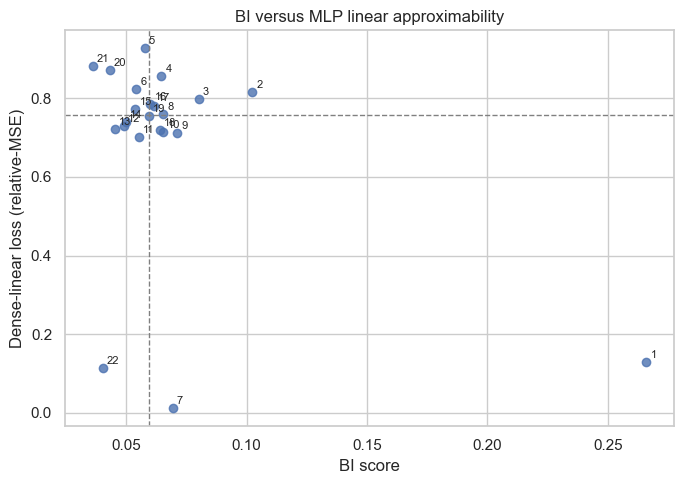

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(
    analysis_df["transformer_layer_bi"],
    analysis_df["linear_relative_mse"],
    alpha=0.8,
)

for _, row in analysis_df.iterrows():
    ax.annotate(
        str(int(row["layer"])),
        (row["transformer_layer_bi"], row["linear_relative_mse"]),
        fontsize=8,
        xytext=(3, 3),
        textcoords="offset points",
    )

ax.axvline(
    analysis_df["transformer_layer_bi"].median(),
    color="gray",
    linestyle="--",
    linewidth=1,
)
ax.axhline(
    analysis_df["linear_relative_mse"].median(),
    color="gray",
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("BI score")
ax.set_ylabel("Dense-linear loss (relative-MSE)")
ax.set_title("BI versus MLP linear approximability")
plt.tight_layout()
plt.show()

tldr: BI score is not that reliable for linear replacement aproximation

MLP score (BI-score equivalent for MLP specificaly)

In [11]:
mlp_residual_bi = compute_mlp_bi_scores(
    model,
    loaders.calibration,
    data_config.num_calibration_batches,
    device,
    layer_indices=eligible_layer_indices,
)

raw_mlp_io = compute_raw_mlp_input_output_scores(
    model,
    loaders.calibration,
    data_config.num_calibration_batches,
    device,
    layer_indices=eligible_layer_indices,
)

analysis_df["mlp_residual_bi"] = (
    analysis_df["layer"].map(
        mlp_residual_bi.scores
    )
)

analysis_df["raw_mlp_io_cosine_distance"] = (
    analysis_df["layer"].map(
        raw_mlp_io.scores
    )
)

analysis_df[
    [
        "layer",
        "transformer_layer_bi",
        "mlp_residual_bi",
        "raw_mlp_io_cosine_distance",
        "linear_relative_mse",
    ]
]

,layer,transformer_layer_bi,mlp_residual_bi,raw_mlp_io_cosine_distance,linear_relative_mse
0,1,0.265937,0.131768,0.890098,0.129797
1,2,0.102373,0.082439,0.884666,0.815188
2,3,0.080143,0.066104,0.882672,0.797848
3,4,0.064685,0.052066,0.994569,0.856134
4,5,0.057725,0.044607,1.029097,0.926072
5,6,0.054293,0.042428,1.072061,0.823105
6,7,0.069344,0.057179,1.177461,0.012034
7,8,0.065373,0.054751,1.224248,0.758450
8,9,0.071133,0.053749,1.240023,0.711282
9,10,0.065534,0.054281,1.222167,0.712977


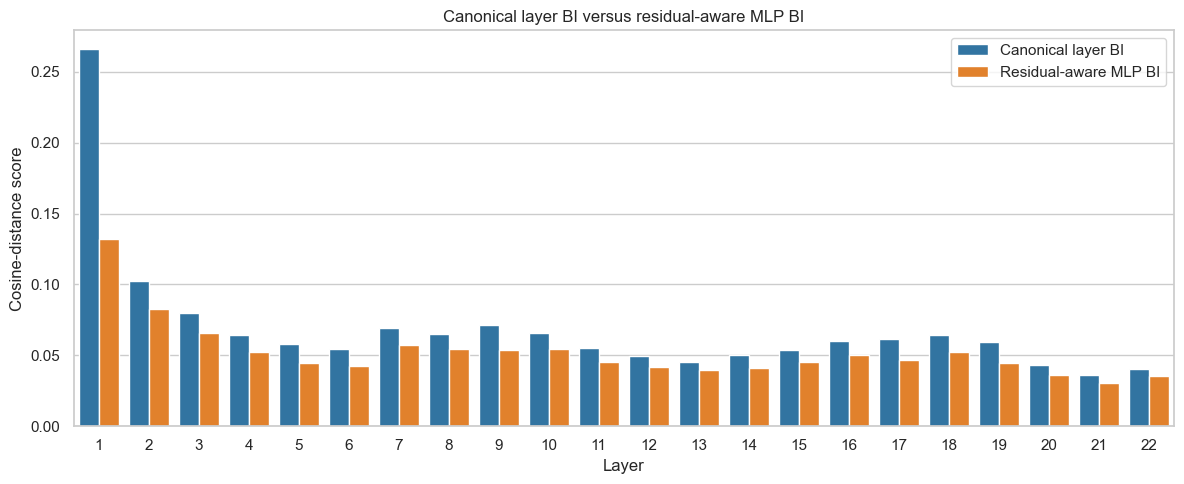

In [12]:
score_long = analysis_df.melt(
    id_vars="layer",
    value_vars=[
        "transformer_layer_bi",
        "mlp_residual_bi",
    ],
    var_name="metric",
    value_name="score",
)

score_long["metric"] = score_long["metric"].map({
    "transformer_layer_bi": "Canonical layer BI",
    "mlp_residual_bi": "Residual-aware MLP BI",
})

fig, ax = plt.subplots(figsize=(12, 5))

sns.barplot(
    data=score_long,
    x="layer",
    y="score",
    hue="metric",
    palette={
        "Canonical layer BI": "tab:blue",
        "Residual-aware MLP BI": "tab:orange",
    },
    ax=ax,
)

ax.set_xlabel("Layer")
ax.set_ylabel("Cosine-distance score")
ax.set_title("Canonical layer BI versus residual-aware MLP BI")
ax.legend(title=None)

plt.tight_layout()
plt.show()

In [13]:
correlations = pd.Series({
    "Canonical BI vs linear relative MSE":
        analysis_df["transformer_layer_bi"].corr(
            analysis_df["linear_relative_mse"],
            method="spearman",
        ),

    "Residual MLP BI vs linear relative MSE":
        analysis_df["mlp_residual_bi"].corr(
            analysis_df["linear_relative_mse"],
            method="spearman",
        ),

    "Canonical BI vs residual MLP BI":
        analysis_df["transformer_layer_bi"].corr(
            analysis_df["mlp_residual_bi"],
            method="spearman",
        ),

    "Raw MLP input-output score vs linear relative MSE":
        analysis_df[
            "raw_mlp_io_cosine_distance"
        ].corr(
            analysis_df["linear_relative_mse"],
            method="spearman",
        ),
}, name="Spearman rho")

correlations.to_frame()

,Spearman rho
Canonical BI vs linear relative MSE,-0.203840
Residual MLP BI vs linear relative MSE,-0.237719
Canonical BI vs residual MLP BI,0.974026
Raw MLP input-output score vs linear relative MSE,-0.424054


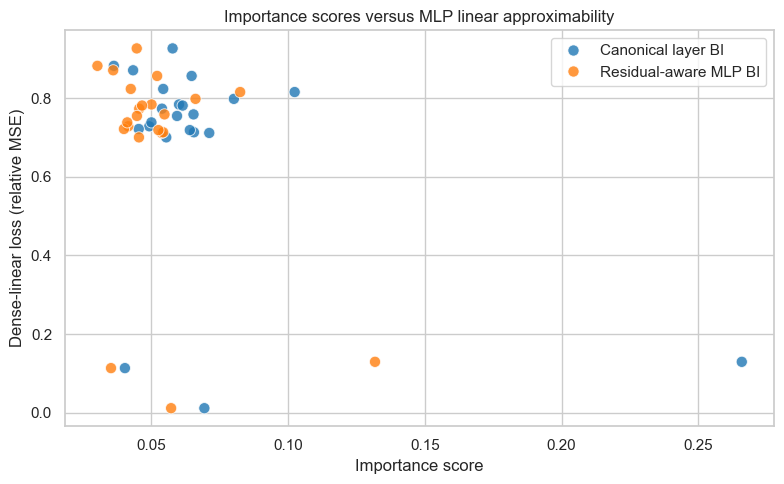

In [14]:
scatter_df = analysis_df.melt(
    id_vars=["layer", "linear_relative_mse"],
    value_vars=[
        "transformer_layer_bi",
        "mlp_residual_bi",
    ],
    var_name="metric",
    value_name="importance_score",
)

scatter_df["metric"] = scatter_df["metric"].map({
    "transformer_layer_bi": "Canonical layer BI",
    "mlp_residual_bi": "Residual-aware MLP BI",
})

fig, ax = plt.subplots(figsize=(8, 5))

sns.scatterplot(
    data=scatter_df,
    x="importance_score",
    y="linear_relative_mse",
    hue="metric",
    palette={
        "Canonical layer BI": "tab:blue",
        "Residual-aware MLP BI": "tab:orange",
    },
    s=65,
    alpha=0.8,
    ax=ax,
)

ax.set_xlabel("Importance score")
ax.set_ylabel("Dense-linear loss (relative MSE)")
ax.set_title(
    "Importance scores versus MLP linear approximability"
)
ax.legend(title=None)

plt.tight_layout()
plt.show()

tldr:

Linear approximability is not supported by purely BI/MLP-residual scores, since there is a slight negative correlation (-0.2), it is therefore useful to do dense linear replacement for testing degradation loss of original operator for replacement operator complexity inference.

Therefore, BI should not be used alone to determine whether an MLP can be
replaced by a linear operator. A subsequent replacement experiment
is needed to test whether local linear approximation error predicts
model-level degradation.

### Block-level Non-linearity testing

### Operator level Importance testing

The idea is to measure importance across different architecture parts in the MLP operator itself. Most MLP operators in LLMs utilize the swiGLU architecture so we can dissect it.

___
Bonus ideas

#### Monte-Carlo Simulation of different activations

using different calibration batches for importance estimation - permumation approach